In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
path_2012 = r"H:\Python\3Etapa\analise_dados\atividade6\Tabela5-sem_emprego_2012.csv"
path_2026 = r"H:\Python\3Etapa\analise_dados\atividade6\Tabela5-sem_emprego_2026.csv"
path_hora = r"H:\Python\3Etapa\analise_dados\atividade2\Tabela 1.1.1.xls"

In [13]:
table_2012 = pd.read_csv(path_2012, encoding="utf-8", sep=";", decimal=",")
table_2012 = table_2012.rename(columns={"Desocupados - mulheres (2012 T1)": "mulheres_2012"})
table_2012 = table_2012.rename(columns={"Desocupados - homens (2012 T1)": "homem_2012"})

In [14]:
table_2012

,Sigla,Código,Estado,homem_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [15]:
table_2026 = pd.read_csv(path_2026, encoding="utf-8", sep=";", decimal = ",")
table_2026 = table_2026.rename(columns={"Desocupados - homens (2026 T1)": "homens_2026"})
table_2026 = table_2026.rename(columns={"Desocupados - mulheres (2026 T1)": "mulheres_2026"})

In [16]:
table_2026

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [17]:
table_result = table_2012.merge(table_2026, on=["Sigla","Código","Estado"], how="inner")
table_result

,Sigla,Código,Estado,homem_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [18]:
bruto = pd.read_excel(path_hora, engine="xlrd", header=None)

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

# horas são número, não texto
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [19]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]

In [20]:
estados = estados.rename(columns = {"uf_regiao": "Estado"})

In [21]:
table_result

,Sigla,Código,Estado,homem_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [22]:
estados

,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
10,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
11,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
12,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


In [23]:

table_result = table_result.merge(estados, on = ["Estado"], how = "inner")

In [24]:
longo = table_result.melt(
    id_vars=["Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)

In [25]:
longo

,Estado,Ano,Participacao_mulheres
0,Acre,mulheres_2012,54.7
1,Alagoas,mulheres_2012,55.3
2,Amazonas,mulheres_2012,52.5
3,Amapá,mulheres_2012,51.9
4,Bahia,mulheres_2012,56.2
5,Ceará,mulheres_2012,48.9
6,Distrito Federal,mulheres_2012,59.0
7,Espírito Santo,mulheres_2012,53.6
8,Goiás,mulheres_2012,59.0
9,Maranhão,mulheres_2012,52.8


In [27]:
ordem = table_result.sort_values("mulheres_2026", ascending=False)["Estado"]

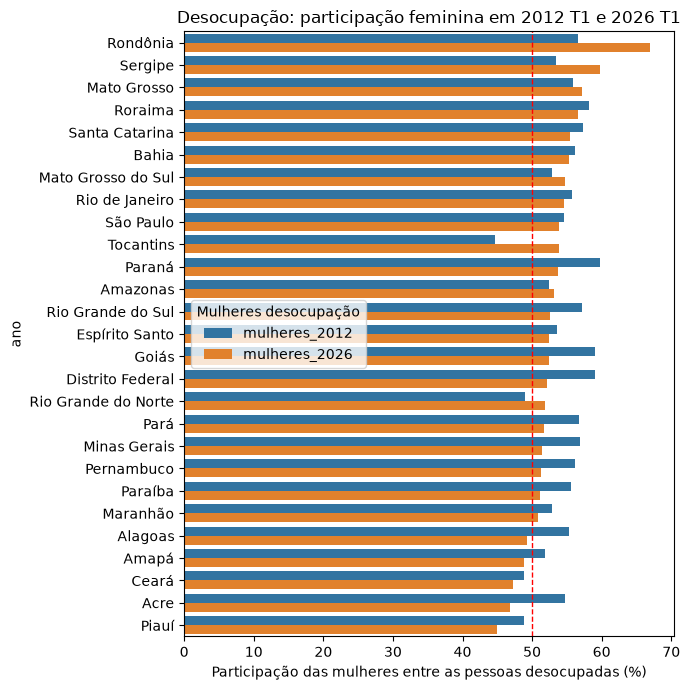

In [28]:


fig, ax = plt.subplots(figsize=(7, 7))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("ano")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Mulheres desocupação")
fig.tight_layout()
plt.show()